<h1><center>Laboratorio 3: La desperación de Mr. Cheems 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1:
- Nombre de alumno 2:


### **Link de repositorio de GitHub:** [Repositorio](https://github.com/...../)

## Temas a tratar
- Aplicar Pandas para obtener características de un DataFrame.
- Aplicar Pipelines y Column Transformers

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.

### Objetivos principales del laboratorio
- Comprender cómo aplicar pipelines de Scikit-Learn para generar procesos más limpios en Feature Engineering.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `numpy`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre arreglos (*o tensores*).

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [162]:
# Libreria Core del lab.
import numpy as np
import pandas as pd
import datetime
from IPython.display import HTML

# Libreria para plotear (En colab esta desactualizado plotly)
!pip install --upgrade plotly
import plotly.express as px
import plotly.graph_objects as go

# Librerias utiles
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [163]:
import matplotlib.pyplot as plt


# Feature engineering en datos de retail 🛍️

### 0. Cargar Dataset

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

Mr. Cheems, gerente de una cotizada tienda de retail en Europa, les solicita si pueden analizar los datos de algunas de sus tiendas. En una reunión, Mr Cheems le comenta que la calidad de sus datos no es muy buena, por lo que le solicita a usted que limpie su base de datos y cree nuevos atributos relevantes para el negocio.

Por ello, el área de ventas les entrega archivo llamado `online_retail_data.pickle` el cual usted decide cargar a continuación.

In [164]:
# Path
path = 'online_retail_data.pickle'

# Base de datos
df_retail = pd.read_pickle(path)
print('Shape:', df_retail.shape)
df_retail.head(10)

Shape: (400947, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,ID489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,ID489434,79323P,PINK CHERRY LIGHTS,12.0,NaT,6.75,13085.0,United Kingdom
2,ID489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,ID489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,ID489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,ID489434,22064,PINK DOUGHNUT TRINKET POT,24.0,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,ID489434,21871,SAVE THE PLANET MUG,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,ID489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10.0,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,ID489435,22350,CAT BOWL,12.0,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,ID489435,22349,"DOG BOWL , CHASING BALL DESIGN",12.0,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


### 1. Función para explorar características [0.5 puntos]

<p align="center">
  <img width=300 src="https://editor.analyticsvidhya.com/uploads/47389meme.png">
</p>




Tras inspeccionar brevemente los datos proporcionados, usted decide crear una función que realice lo siguiente:
- Plotee un histograma para las variables precios y cantidad. [0.3 puntos]
- Imprima un conteo de datos nulos por variable [0.2 puntos]

**Nota**: Para generar los gráficos no es obligatorio el uso de `plotly`, pero si es altamente recomendado. Pueden encontrar más información de esta librería en este [enlace](https://plotly.com/python/).

**Respuesta:**

In [ ]:
import matplotlib.pyplot as plt

def explorar_datos(df, log_scale=False, max_price=50, max_qty=100):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Filtrar valores muy grandes
    precios = df['Price'].dropna()
    precios = precios[(precios > 0) & (precios <= max_price)]

    cantidades = df['Quantity'].dropna()
    cantidades = cantidades[(cantidades > 0) & (cantidades <= max_qty)]

    # Histograma precios
    axes[0].hist(precios, bins=50, edgecolor='black')
    axes[0].set_title("Histograma de Precios")
    axes[0].set_xlabel("Precio")
    axes[0].set_ylabel("Frecuencia")
    if log_scale:
        axes[0].set_xscale("log")

    # Histograma cantidades
    axes[1].hist(cantidades, bins=50, edgecolor='black')
    axes[1].set_title("Histograma de Cantidad")
    axes[1].set_xlabel("Cantidad")
    axes[1].set_ylabel("Frecuencia")
    if log_scale:
        axes[1].set_xscale("log")

    plt.tight_layout()
    plt.show()

    # Conteo de nulos
    print("Conteo de valores nulos por columna:")
    print(df.isnull().sum())



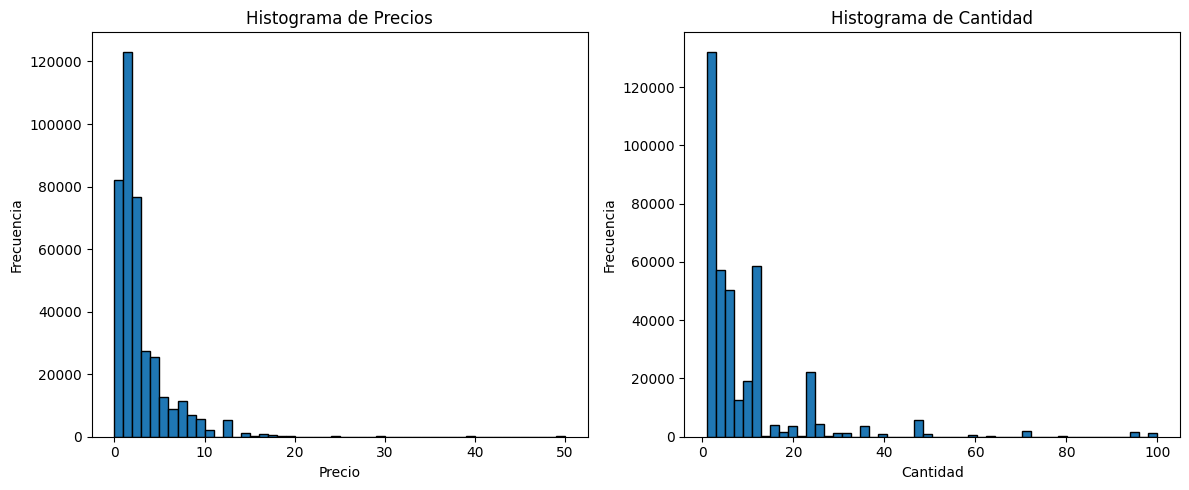

Conteo de valores nulos por columna:
Invoice           0
StockCode         0
Description       0
Quantity       7915
InvoiceDate    9308
Price          8356
Customer ID       0
Country        8164
dtype: int64


In [166]:
explorar_datos(df_retail)

### 2. Eliminando outliers [1.0 puntos]

<p align="center">
  <img width=300 src="https://media.licdn.com/dms/image/C5612AQGdXKCka7HumA/article-cover_image-shrink_600_2000/0/1520056407281?e=2147483647&v=beta&t=VZcfjjzjK4LxXdZkSu1KisWC0Ry8bk4tPCn3R8aYdNM">
</p>




#### 2.1 Creando la clase IQR [0.5 puntos]

Entre las falencias de los datos, Mr. Cheems le comenta que a veces los operadores no ingresan el precio correcto de los productos. Mr. Cheems le comenta que se dio cuenta de este fenómeno porque hay productos con precios exagerádamente altos o bajos. Por lo cual usted decide eliminar outliers del dataframe a traves del rango intercuartil el cual cuenta con los siguientes pasos:

1. Calcular el primer cuartil $Q1$ y el tercer cuartil $Q3$. Hint: utilice el método `quantile()`

2. Calcular el rango intercuartil (RIC): $RIC = Q3 - Q1$

3. Calcular los límites para identificar outliers:
 - Límite inferior: $~~Q1 - \lambda \cdot RIC$
 - Límite superior: $~~Q3 + \lambda \cdot RIC$

4. Eliminar outliers: Los outliers son los datos que están por debajo del límite inferior o por encima del límite superior.


Para realizar dicha tarea, usted decide crear una clase llamada `IQR()` utilizando `BaseEstimator` y `TransformerMixin` para realizar una transformación de cada una de las columnas numéricas del DataFrame utilizando `ColumnTransformer()` más tarde. Considere que lambda debe ser $\lambda$ un parámetro a definir por el usuario.

**Hint:** tome como referencia el siguiente [enlace](https://sklearn-template.readthedocs.io/en/latest/user_guide.html#transformer).

**Nota:** No modificar el método set_output de la clase IQR

**Respuesta:**

In [167]:

class IQR(BaseEstimator, TransformerMixin):

    def __init__(self, lmbda=1.5):
        self.lmbda = lmbda

    def fit(self, X, y=None):
        # Solo calculamos para columnas numéricas
        X_numeric = X.select_dtypes(include=np.number)
        self.Q1_ = X_numeric.quantile(0.25)
        self.Q3_ = X_numeric.quantile(0.75)
        self.RIC_ = self.Q3_ - self.Q1_
        return self

    def transform(self, X):
        X_out = X.copy()
        X_numeric = X_out.select_dtypes(include=np.number)

        # Límites
        lower = self.Q1_ - self.lmbda * self.RIC_
        upper = self.Q3_ + self.lmbda * self.RIC_

        # Si cualquier numérica es outlier, se elimina la fila
        mask = np.ones(len(X_out), dtype=bool)
        for col in X_numeric.columns:
            mask &= (X_numeric[col] >= lower[col]) & (X_numeric[col] <= upper[col])

        return X_out[mask]

    def set_output(self, transform='default'):
        return self


In [168]:
IQR_class = IQR(lmbda=1.5)
IQR_class.fit(df_retail)
df_retailOut = IQR_class.transform(df_retail)
df_retailOut.shape


(328514, 8)

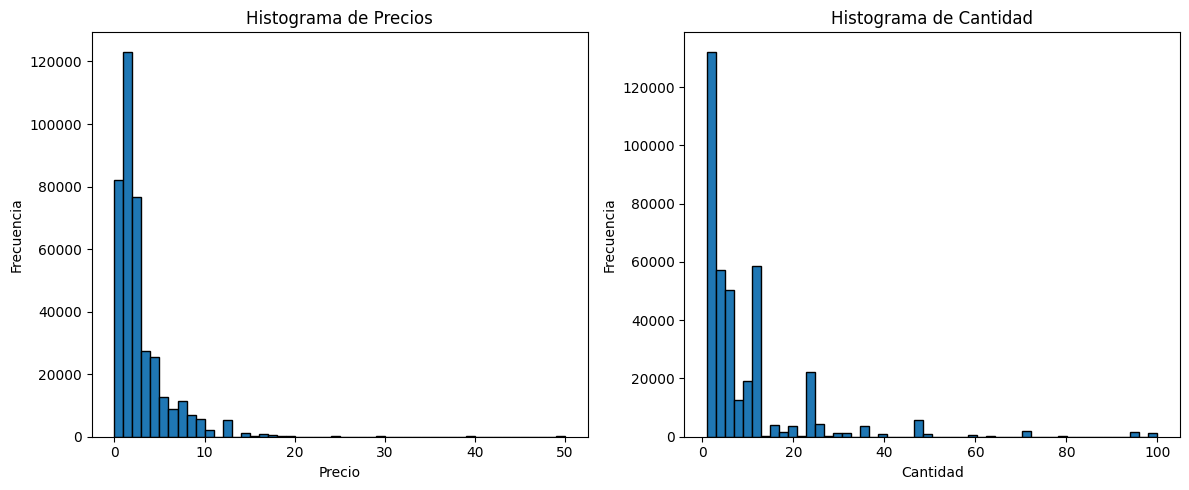

Conteo de valores nulos por columna:
Invoice           0
StockCode         0
Description       0
Quantity       7915
InvoiceDate    9308
Price          8356
Customer ID       0
Country        8164
dtype: int64


In [169]:
explorar_datos(df_retail)

#### 2.2 Creación del Pipeline [0.5 puntos]

Para comenzar introduciéndose en el uso de pipeline, usted decide definir un pipeline con el Transformer previamente definido. Además, usted decide visualizar cómo cambia la distribución de las variables Precio y Cantidad antes y despues de aplicar IQR. Para ello, usted aplica los siguientes pasos:

- Definir un pipeline llamado `numeric_transformations` para las variables precio y cantidad con la transformación IQR. [0.1 puntos]
- Defina un column transformer que aplique `numeric_transformations` para las variables numéricas y `passthrough` para las variables categóricas. Adicionalmente, fije el parámetro `verbose_feature_names_out` en `False`. Ver hint al final [0.1 puntos]
- Defina el dataframe `df_iqr` aplicado el column transformer a los datos proporcionados por Mr. Cheems considerando un valor de $\lambda$ que tenga un desempeño aceptable para ambas variables. [0.1 puntos]
- Usar `explore_data` en `df_retail` y en `df_iqr`.  [0.1 puntos]
- Reportar los cambios observados en la distribución de las variables. ¿Qué sucede al aumentar el valor de lambda? [0.1 puntos]


**Hint:** El transformador `passthrough` está predefinido y es una opción que puedes usar para las columnas que no deseas transformar. Al especificar 'passthrough' para una parte de tu ColumnTransformer, las columnas correspondientes pasarán a través del ColumnTransformer sin ninguna modificación. El siguiente [enlace](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) le puede ser útil.

**Nota:** Mantenga el método set_output del column transformer con la transformación `pandas` para obtener un dataframe una vez aplicado el column transformer.

**Respuesta:**

Apóyese de la siguiente estructura para su respuesta:

In [170]:
# Definicion las variables que pasarán por cada pipeline
numerical_columns = ['Price', 'Quantity']
categorical_columns = ['Invoice', 'StockCode', 'Description', 'InvoiceDate', 'Customer ID', 'Country']

# Definicion del pipeline
numeric_transformations = Pipeline([
    ('iqr', IQR(lmbda=1.5))  
])
# ColumnTransformer
column_transformer = ColumnTransformer(
    transformers=[
        ('numerical', numeric_transformations, numerical_columns),
        ('categorical', 'passthrough', categorical_columns)
    ],
    verbose_feature_names_out=False
)

column_transformer.set_output(transform='pandas')


# ColumnTransformer a los datos
df_iqr = column_transformer.fit_transform(df_retail)



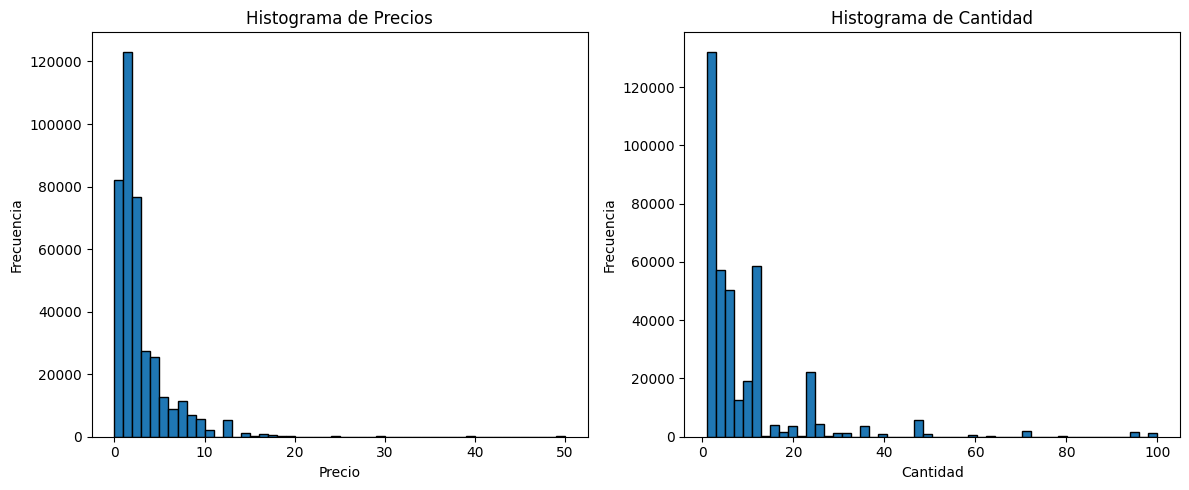

Conteo de valores nulos por columna:
Invoice           0
StockCode         0
Description       0
Quantity       7915
InvoiceDate    9308
Price          8356
Customer ID       0
Country        8164
dtype: int64


In [171]:
explorar_datos(df_retail)

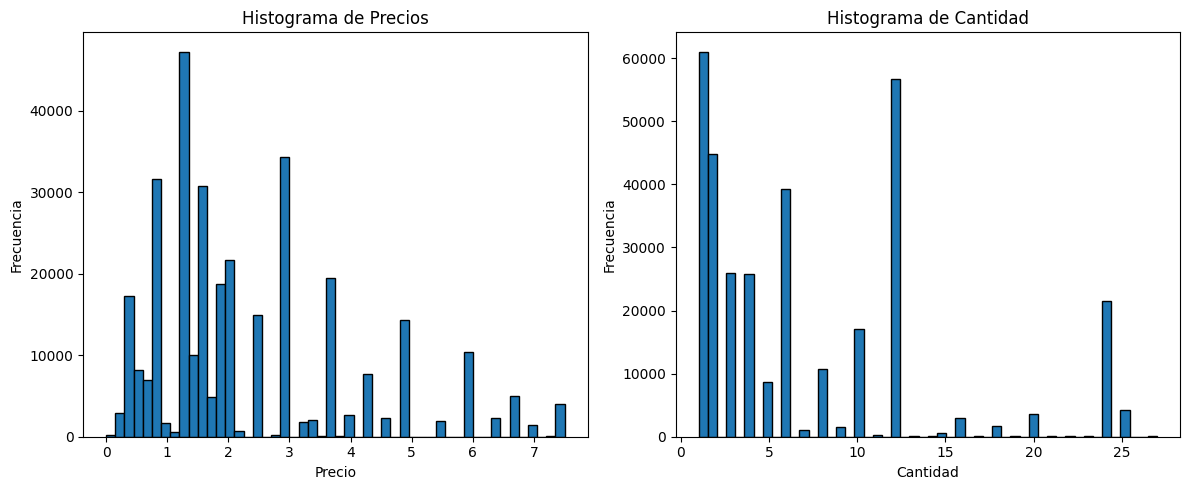

Conteo de valores nulos por columna:
Price          72433
Quantity       72433
Invoice            0
StockCode          0
Description        0
InvoiceDate     9308
Customer ID        0
Country         8164
dtype: int64


In [172]:
explorar_datos(df_iqr)

*Reporte los cambios observados aquí.*

### 3. Agregando un imputer al pipeline [1.0 puntos]



<p align="center">
  <img width=300 src="https://media.makeameme.org/created/hmm-there-is.jpg">
</p>

Para continuar con la limpieza del dataframe usted decide imputar los datos nulos de las variables numéricas, para lo cual decide realizar las siguientes tareas:

1. Crear un pipeline para variables categóricas llamado `categoric_transformations` con un paso llamado `mode_imputer`, en el cual se imputen los datos faltantes por la categoría más frecuente.
2. Agregar al pipeline `numeric_transformations` un paso llamado `mean_imputer`, en el cual se imputen los datos por la media usando [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) [0.1 puntos]
3. Crear y aplicar un `ColumnTransformer` actualizado con los pipelines `categoric_transformations` y `numeric_transformations` a `df_retail`, creando un dataframe llamado `df_mean_imputer`. [0.1 puntos]
4. Comparar los resultados de `explore_data` en `df_mean_imputer` y `df_iqr`. ¿Qué diferencias observa en la distribución de los datos? [0.2 puntos]
5. Cambiar el imputer de `numeric_transformations` por [KNNImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html) y definir un nuevo dataframe llamado `df_knn_imputer`, aplicando el nuevo ColumnTransformer a `df_retail`. En caso de los tiempos de ejecución sean altos puede probar a reducir el parámetro `n_neighbors`. [0.1 puntos]
6. Comparar los resultados de `explore_data` en `df_knn_imputer` y `df_iqr`. ¿Qué diferencias observa en la distribución de los datos? [0.2 puntos]
7. Comparar los resultados de `explore_data` en `df_knn_imputer` y `df_mean_imputer`. ¿Cuál método de imputación es mejor? Deje el método escogido en el ColumnTransformer. [0.2 puntos]

**Nota: Fije el parámetro verbose_feature_names_out en `False` y utilice el método set_output con transformación `pandas` en cada ColumnTransformer para obtener como salida un dataframe.**

**Respuesta:**

In [173]:
from sklearn.impute import SimpleImputer

In [ ]:
numerical_columns = ['Quantity', 'Price']
categorical_columns = ['Invoice', 'StockCode', 'Description', 
                       'InvoiceDate', 'Customer ID', 'Country']

In [174]:
categoric_transformations = Pipeline([
    ('mode_imputer', SimpleImputer(strategy='most_frequent'))
])
numeric_transformations = Pipeline([
    ('iqr', IQR(lmbda=1.5)),                 
    ('mean_imputer', SimpleImputer(strategy='mean'))  
])

In [ ]:
column_transformer = ColumnTransformer([
    ('numerical', numeric_transformations, numerical_columns),
    ('categorical', categoric_transformations, categorical_columns)
], verbose_feature_names_out=False)

column_transformer.set_output(transform='pandas')

# Aplicamos la transformación
df_mean_imputer = column_transformer.fit_transform(df_retail)

In [176]:
from sklearn.impute import KNNImputer

In [177]:
numeric_transformations_knn = Pipeline([
    ('iqr', IQR(lmbda=1.5)),
    ('knn_imputer', KNNImputer(n_neighbors=3))  # puedes ajustar n_neighbors
])

column_transformer_knn = ColumnTransformer([
    ('numerical', numeric_transformations_knn, numerical_columns),
    ('categorical', categoric_transformations, categorical_columns)
], verbose_feature_names_out=False)

column_transformer_knn.set_output(transform='pandas')

# Aplicamos la transformación
df_knn_imputer = column_transformer_knn.fit_transform(df_retail)

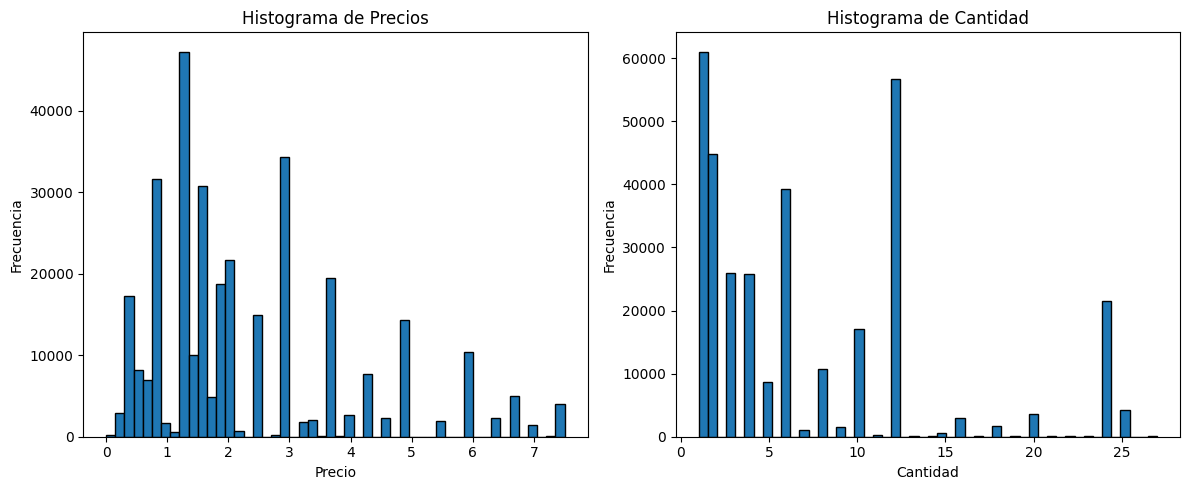

Conteo de valores nulos por columna:
Quantity       72433
Price          72433
Invoice            0
StockCode          0
Description        0
InvoiceDate        0
Customer ID        0
Country            0
dtype: int64


In [178]:
explorar_datos(df_mean_imputer)


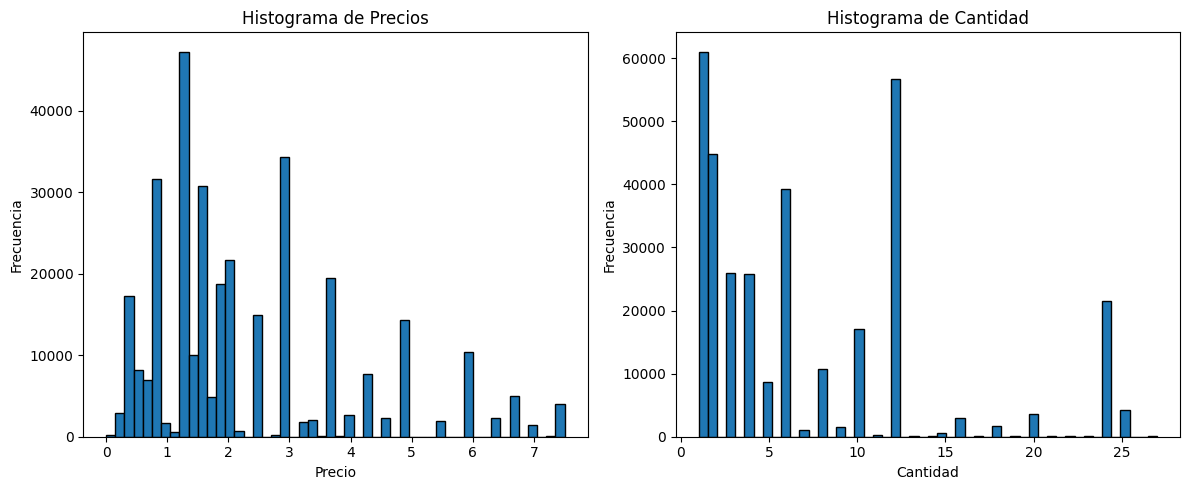

Conteo de valores nulos por columna:
Quantity       72433
Price          72433
Invoice            0
StockCode          0
Description        0
InvoiceDate        0
Customer ID        0
Country            0
dtype: int64


In [179]:
explorar_datos(df_knn_imputer)


*Escriba su respuesta aquí*

### 4. Creación de nuevas features [2.0 puntos]

<p align="center">
  <img width=250 src="https://miro.medium.com/max/1000/1*JtTWgAcfVTWV8OTjT47Atg.jpeg">
</p>


#### 4.1 Definicion de LRMFP [1.0 puntos]

Dado que Mr. Lepin está interesado en obtener nuevos atributos relevantes para su negocio, su equipo de expertos sugiere la construcción de variables **LRMFP**, las que se construyen en base a las siguientes definiciones:

- **Length (L)**: Intervalo de tiempo, en días, entre la primera y la última visita del cliente. Mientras mas grande sea el valor, mas fiel es el cliente.

- **Recency (R)**: Indica hace cuanto tiempo el cliente realizo su ultima compra. Notar que para este caso, mientras mas grande es el valor, menos interes posee el usuario para repetir una compra en uno de los locales. **Considere "hoy" como la fecha mas reciente del dataset**.

- **Monetary (M)**: El término "monetario" se refiere a la cantidad media de dinero gastada por cada visita del cliente durante el período de observación y refleja la contribución del cliente a los ingresos de la empresa.

- **Frequency (F)**: Se refiere al número total de visitas del cliente durante el periodo de observación. Cuanto mayor sea la frecuencia, mayor será la fidelidad del cliente.

- **Periodicity (P)**: Representa si los clientes visitan las tiendas con regularidad.

$$Periodicity(n)=std(IVT_1, ..., IVT_n)$$

Donde $IVT$ denota el tiempo entre visitas y n representa el número de valores de tiempo entre visitas de un cliente.


$$IVT_i=date\_diff(t_{i+1},t)$$

En base a las definiciones señaladas, diseñe una función que permita obtener las características **LRMFP** recibiendo un DataFrame como entrada. Para esto, no estará permitido el uso de iteradores, utilice todas las herramientas que les ofrece `pandas` para realizar esto.

Una referencia que le puede ser útil es el [documento original](https://www.researchgate.net/publication/315979555_LRFMP_model_for_customer_segmentation_in_the_grocery_retail_industry_a_case_study) en donde se propone este método.

**<u>Formato</u> del Resultado Esperado:**

| Customer ID | Length | Recency | Frequency | Monetary | Periodicity |
|------------:|-------:|--------:|----------:|---------:|------------:|
|   12346.0   |    294 |      67 |        46 |   -64.68 |        37.0 |
|   12347.0   |     37 |       3 |        71 |  1323.32 |         0.0 |
|   12349.0   |    327 |      43 |       107 |  2646.99 |        78.0 |
|   12352.0   |     16 |      11 |        18 |   343.80 |         0.0 |
|   12356.0   |     44 |      16 |        84 |  3562.25 |        12.0 |

**Respuesta:**

In [180]:
def custom_features(dataframe_in):
    pass

#### 4.2 Agregando las custom features [1.0 puntos]

Ahora, usted decide agregar al pipeline las nuevas variables creadas, para lo cual realiza las siguientes tareas:

1. Cree un nuevo pipeline llamado `retail_pipeline` que encapsule el ColumnTransformer y calcule las LRMFP. El primer paso del pipeline llámelo  `col_tranformer` y el segundo paso llámelo `custom_features`, incorpora las nuevas variables al dataframe. Hint: les puede ser útil investigar [este](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.FunctionTransformer.html) método. [0.1 puntos]
2. Aplicar el pipeline actualizado a los datos proporcionados por Mr. Cheems, creando un nuevo dataframe llamado `df_custom`. [0.1 puntos]
3. Explorar la distribución de las nuevas variables con `explore_data` y comentar brevemente (2-3 líneas) características de cada custom feature. [0.5 puntos]
5. Entregar un insight para el negocio en base a las nuevas variables. [0.3 puntos]

**Nota:** Recuerde fijar el parámetro `verbose_feature_names_out` en `False` e incorporar el método `set_output` para obtener una salida en formato dataframe del ColumnTransformer.

**Respuesta**

### 5. MinMax Scaler [1.0 puntos]

<p align="center">
  <img width=300 src="https://i.imgflip.com/1fsprn.jpg">
</p>


#### 5.1 Definición del Column Transformer [0.5 puntos]

Construya una clase llamada `MinMax()` para realizar una transformación de cada una de las columnas de un DataFrame utilizando `ColumnTransformer()`. Recuerde  usar `BaseEstimator` y `TransformerMixin`.


 Para esto considere que Min-Max escaler queda dada por la ecuación:

$$MinMax = \dfrac{x-min(x)}{max(x) - min(x)}$$


Consulte el siguiente [link](https://sklearn-template.readthedocs.io/en/latest/user_guide.html#transformer) si tiene dudas sobre la creación de custom transformers.

**Respuesta:**

In [181]:
class MinMax(BaseEstimator, TransformerMixin):

    def fit(self,X):
        #Agregar código aquí
        pass

    def transform(self,X):
        #Agregar código aquí
        pass

    def set_output(self,transform='default'):
        #No modificar este método
        return self



#### 5.2 Incorporando MinMax al pipeline [0.5 puntos]

Ahora, usted decide agregar el escalamiento al pipeline, para lo que decide seguir los siguientes pasos:

- Agregar el paso `minmax` al pipeline `numeric_transformations`, haciendo uso de la clase creada. [0.1 puntos]
- Defina el dataframe `df_minmax` aplicando el ColumnTransformer actualizado a los datos proporcionados por Mr. Cheems. [0.1 puntos]
- Usar `explore_data` en `df_retail` y en `df_minmax`. [0.1 puntos]
- Reportar los cambios observados en la distribución de las variables.  [0.2 puntos]

**Nota:** Recuerde fijar el parámetro `verbose_feature_names_out` en `False` e incorporar el método `set_output` para obtener una salida en formato dataframe del ColumnTransformer.

**Respuesta:**

### 6. Pregunta teórica [0.5 puntos]

<p align="center">
  <img width=300 src="https://file.coinexstatic.com/2023-09-19/166BAC031F222E5910954E7D7D0BC844.png">
</p>

Finalmente, explíquele a Mr. Cheems porqué es útil la creación de pipelines al momento de hacer Feature Engineering en Machine Learning.

**Respuesta:**

*Escriba su respuesta aquí*